In [1]:
import sys
sys.path.append("src/")

from data_handler import getData
from feature_selector import fitCorrelationFilter, applyCorrelationFilter
from linear_models import LogisticRegressionModel, PocketModel, MajorityClassModel
from svm import LinearSVMModel
from tree_models import RandomForestModel, LightGBMModel
from nn import NeuralNetworkModel
from knn import KNNModel
from evaluator import evaluateAll, plotConfusionMatrix

In [2]:
X_train, X_val, X_test, y_train, y_val, y_test, scaler, features = getData()

[loadData] Loaded 88,647 rows x 112 columns
[loadData] Dropped 1,438 duplicate rows
[loadData] Class balance:
phishing
0    56712
1    30497
[loadData] No missing values found.
[loadData] Final dataset: 87,209 rows x 112 columns

[splitData] Train : 52,325 samples (60.0%)
[splitData] Val   : 17,442 samples (20.0%)
[splitData] Test  : 17,442 samples (20.0%)
[splitData] Train positive rate: 0.350
[splitData] Val positive rate: 0.350
[splitData] Test positive rate: 0.350
[normalizeData] Normalization fit on training set only.
[normalizeData] Mean of first feature (train): -0.000000 (should be ~0)
[normalizeData] Std  of first feature (train): 1.000010  (should be ~1)

[getData] Ready. Features: 111


In [3]:
features_to_keep = fitCorrelationFilter(X_train)
X_train = applyCorrelationFilter(X_train, features_to_keep)
X_val   = applyCorrelationFilter(X_val,   features_to_keep)
X_test  = applyCorrelationFilter(X_test,  features_to_keep)

[featureSelector] Threshold=0.9 | 111 -> 72 features (39 dropped)


In [4]:
from knn import KNNModel

k_values = [5, 10, 20, 50, 100, 200, 250]
knn_results = []

for k in k_values:
    m = KNNModel(k=k)
    m.train(X_train, y_train)
    metrics = m.evaluate(X_val, y_val)
    metrics["k"] = k
    knn_results.append(metrics)
    print(f"k={k} | AUC: {metrics['roc_auc']} | F1: {metrics['f1']} | Acc: {metrics['accuracy']}")

# Pick best k
best_k = max(knn_results, key=lambda x: x["roc_auc"])["k"]
print(f"\nBest k: {best_k}")

[kNN] Fitted in 0.0s (k=5)
k=5 | AUC: 0.9803 | F1: 0.9292 | Acc: 0.9506
[kNN] Fitted in 0.01s (k=10)
k=10 | AUC: 0.9847 | F1: 0.9251 | Acc: 0.9482
[kNN] Fitted in 0.0s (k=20)
k=20 | AUC: 0.9857 | F1: 0.9214 | Acc: 0.9452
[kNN] Fitted in 0.0s (k=50)
k=50 | AUC: 0.9846 | F1: 0.912 | Acc: 0.9381
[kNN] Fitted in 0.0s (k=100)
k=100 | AUC: 0.9826 | F1: 0.9029 | Acc: 0.9314
[kNN] Fitted in 0.0s (k=200)
k=200 | AUC: 0.9804 | F1: 0.8938 | Acc: 0.9241
[kNN] Fitted in 0.0s (k=250)
k=250 | AUC: 0.9793 | F1: 0.8896 | Acc: 0.9211

Best k: 20


In [5]:
models = [
    MajorityClassModel(),
    LogisticRegressionModel(),
    PocketModel(),
    LinearSVMModel(),
    RandomForestModel(),
    LightGBMModel(),
    NeuralNetworkModel(),
    KNNModel(k=best_k),
]

for model in models:
    model.train(X_train, y_train)

[Majority Class] Trained
[Logistic Regression] Trained in 0.12s
[SLP Pocket] Trained in 1.21s | Best train error: 0.0786
[SVM (Linear)] Trained in 256.8s
[Random Forest] Trained in 0.5s
[LightGBM] Trained in 0.6s
[Neural Network] Trained in 5.9s
[kNN] Fitted in 0.01s (k=20)


In [6]:
results = evaluateAll(models, X_val, y_val, title="Initial Results")

  Majority Class — AUC: None | F1: 0.0 | Acc: 0.6503
  Logistic Regression — AUC: 0.9799 | F1: 0.9066 | Acc: 0.934
  SLP Pocket — AUC: 0.9686 | F1: 0.8896 | Acc: 0.9215
  SVM (Linear) — AUC: 0.9797 | F1: 0.9041 | Acc: 0.9315
  Random Forest — AUC: 0.9947 | F1: 0.9541 | Acc: 0.9677
  LightGBM — AUC: 0.9942 | F1: 0.9488 | Acc: 0.9642
  Neural Network — AUC: 0.9908 | F1: 0.9402 | Acc: 0.9584
  kNN — AUC: 0.9857 | F1: 0.9214 | Acc: 0.9452

  Initial Results
                 model  roc_auc  accuracy      f1  precision  recall
1        Random Forest   0.9947    0.9677  0.9541     0.9498  0.9584
2             LightGBM   0.9942    0.9642  0.9488     0.9487  0.9489
3       Neural Network   0.9908    0.9584  0.9402     0.9465  0.9339
4                  kNN   0.9857    0.9452  0.9214     0.9250  0.9179
5  Logistic Regression   0.9799    0.9340  0.9066     0.8966  0.9169
6         SVM (Linear)   0.9797    0.9315  0.9041     0.8863  0.9226
7           SLP Pocket   0.9686    0.9215  0.8896     0.874

In [4]:
from evaluator import evaluateFinal

model_paths = {
    "RF (Tuned)":          "models/rf_tuned.pkl",
    "LightGBM (Tuned)":    "models/lgbm_tuned.pkl",
    "NN (Weight Decay)":   "models/nn_wd.pkl",
    "NN (Early Stopping)": "models/nn_es.pkl",
}

final_results = evaluateFinal(model_paths, X_test, y_test)

/Users/eliavohaion/Desktop/Binghamton University/Intro to ML/Extra Credit/venv/lib/python3.14/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator DecisionTreeClassifier from version 1.6.1 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/Users/eliavohaion/Desktop/Binghamton University/Intro to ML/Extra Credit/venv/lib/python3.14/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator RandomForestClassifier from version 1.6.1 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


RF (Tuned) — AUC: 0.9955 | F1: 0.9586 | Acc: 0.971


/Users/eliavohaion/Desktop/Binghamton University/Intro to ML/Extra Credit/venv/lib/python3.14/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator LabelEncoder from version 1.6.1 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


LightGBM (Tuned) — AUC: 0.9963 | F1: 0.9624 | Acc: 0.9737
NN (Weight Decay) — AUC: 0.9907 | F1: 0.9397 | Acc: 0.958
NN (Early Stopping) — AUC: 0.9899 | F1: 0.9362 | Acc: 0.9555

  Final Results (Test Set)
                 model  roc_auc  accuracy      f1  precision  recall
1     LightGBM (Tuned)   0.9963    0.9737  0.9624     0.9637  0.9611
2           RF (Tuned)   0.9955    0.9710  0.9586     0.9575  0.9597
3    NN (Weight Decay)   0.9907    0.9580  0.9397     0.9442  0.9352
4  NN (Early Stopping)   0.9899    0.9555  0.9362     0.9391  0.9333



/Users/eliavohaion/Desktop/Binghamton University/Intro to ML/Extra Credit/venv/lib/python3.14/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator LabelBinarizer from version 1.6.1 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/Users/eliavohaion/Desktop/Binghamton University/Intro to ML/Extra Credit/venv/lib/python3.14/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator MLPClassifier from version 1.6.1 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/Users/eliavohaion/Desktop/Binghamton University/Intro to ML/Extra Credit/venv/

/Users/eliavohaion/Desktop/Binghamton University/Intro to ML/Extra Credit/venv/lib/python3.14/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator LabelEncoder from version 1.6.1 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/Users/eliavohaion/Desktop/Binghamton University/Intro to ML/Extra Credit/venv/lib/python3.14/site-packages/shap/explainers/_tree.py:620: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


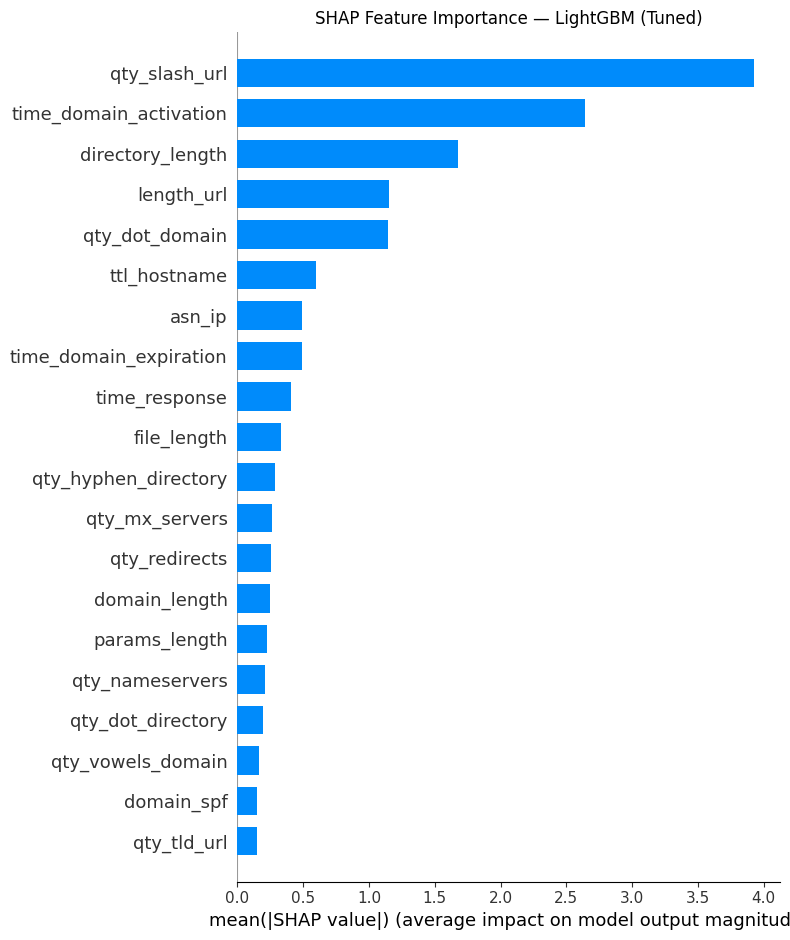

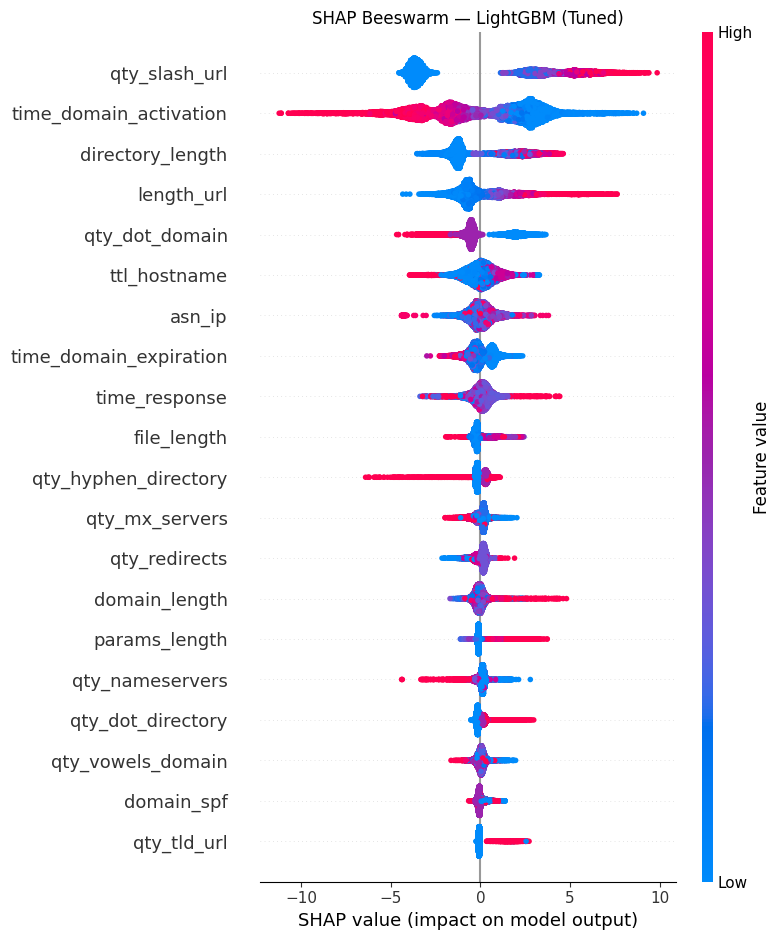

In [5]:
import shap
import matplotlib.pyplot as plt

# Load tuned LightGBM
import joblib
lgbm_tuned = joblib.load("models/lgbm_tuned.pkl")

# SHAP TreeExplainer
explainer   = shap.TreeExplainer(lgbm_tuned)
shap_values = explainer.shap_values(X_test)

# For binary classification shap_values is a list [class0, class1]
if isinstance(shap_values, list):
    shap_values = shap_values[1]

# Bar chart — mean absolute SHAP value
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test, plot_type="bar", show=False)
plt.title("SHAP Feature Importance — LightGBM (Tuned)")
plt.tight_layout()
plt.savefig("shap_bar.png", dpi=150, bbox_inches="tight")
plt.show()

# Beeswarm — direction and magnitude
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test, show=False)
plt.title("SHAP Beeswarm — LightGBM (Tuned)")
plt.tight_layout()
plt.savefig("shap_beeswarm.png", dpi=150, bbox_inches="tight")
plt.show()